# 02 — Factor & Residual Analysis

Computes **factor scores** (momentum, value, quality, growth) for every stock, runs **OLS market/sector regressions**, extracts residuals, and clusters the universe via **PCA** and **hierarchical clustering**.

**Inputs:** `data/prices.parquet`, `data/returns.parquet`, `data/fundamentals.parquet`  
**Outputs:** `data/factor_scores.parquet`, `data/betas.parquet`, `data/residuals.parquet`

In [1]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
sys.path.insert(0, '.')
from config import *
print('Ready.')

Ready.


In [2]:
prices   = pd.read_parquet(DATA_DIR + 'prices.parquet')
returns  = pd.read_parquet(DATA_DIR + 'returns.parquet')
fund_df  = pd.read_parquet(DATA_DIR + 'fundamentals.parquet')

ALL_STOCKS  = [LONG_CANDIDATE] + SHORT_CANDIDATES
ALL_TICKERS = ALL_STOCKS + [SECTOR_ETF, MARKET_INDEX]

stock_px  = prices[ALL_STOCKS]
stock_ret = returns[ALL_STOCKS]
mkt_ret   = returns[MARKET_INDEX]
sec_ret   = returns[SECTOR_ETF]

print(f'Prices : {prices.shape}')
print(f'Returns: {returns.shape}')
print(f'Funds  : {fund_df.shape}')
print(f'Universe: {ALL_STOCKS}')

Prices : (1101, 18)
Returns: (1100, 18)
Funds  : (16, 20)
Universe: ['GEVO', 'CHPT', 'BE', 'RUN', 'ARRY', 'HYLN', 'RIVN', 'LCID', 'GOEV', 'ALTO', 'REI', 'PARR', 'AFRM', 'GPRE', 'PLUG', 'AMTX']


## 1. Factor Scores

| Factor | Proxy |
|---|---|
| **Momentum** | 12-1 month total return |
| **Short Momentum** | 1-month return |
| **Value** | 1 / Forward P/E (normalized) |
| **Quality** | ROE - Debt/Equity ratio (normalized) |
| **Growth** | Revenue growth YoY (normalized) |
| **Low Vol** | Negative of 1-year realized vol |

In [3]:
def zscore_cross_section(series):
    """Cross-sectional z-score (rank-based for robustness)."""
    return series.rank().sub(series.rank().mean()).div(series.rank().std())

# ── Momentum factors (price-based) ───────────────────────────────────────────
days_12m = min(252, len(stock_px) - 1)
days_1m  = min(21,  len(stock_px) - 1)

momentum_12_1 = stock_px.pct_change(days_12m - 21).iloc[-1]   # 12m excl. last month
momentum_1m   = stock_px.pct_change(days_1m).iloc[-1]          # 1-month

# ── Volatility (low-vol factor = negative of vol) ────────────────────────────
low_vol = -(stock_ret.std() * np.sqrt(252))

print('Price-based factors:')
pd.DataFrame({
    'Momentum 12-1': momentum_12_1,
    'Momentum 1m':   momentum_1m,
    'Low Vol':        low_vol
}).round(4)

Price-based factors:


,Momentum 12-1,Momentum 1m,Low Vol
Ticker,,,
GEVO,1.1818,0.2903,-0.9359
CHPT,-0.6164,-0.2612,-0.8111
BE,6.2298,-0.1344,-0.8500
RUN,1.0537,0.2262,-0.9400
ARRY,0.5795,0.0067,-0.8370
HYLN,0.1589,-0.1337,-0.8644
RIVN,0.0937,-0.0106,-0.7823
LCID,-0.6191,-0.0544,-0.8114
GOEV,0.0000,0.0000,-1.1453


In [4]:
# ── Fundamental factors ──────────────────────────────────────────────────────
# fund_df is saved with tickers as index rows; reindex handles missing tickers gracefully
fund_num = fund_df.reindex(ALL_STOCKS).copy()

# Ensure all columns are numeric
for col in fund_num.columns:
    fund_num[col] = pd.to_numeric(fund_num[col], errors='coerce')

# Value: inverse forward P/E (higher = cheaper)
pe_fwd = fund_num.get('pe_forward', pd.Series(dtype=float))
value  = (1.0 / pe_fwd).where(pe_fwd > 0)  # exclude negatives

# Quality: ROE minus leverage proxy
roe  = fund_num.get('roe',         pd.Series(dtype=float))
de   = fund_num.get('debt_equity', pd.Series(dtype=float))
quality = roe - (de / 100).clip(0)  # de is often in % units from Yahoo

# Growth: revenue growth
growth = fund_num.get('revenue_growth', pd.Series(dtype=float))

# Gross margin (additional quality signal)
margin = fund_num.get('gross_margin', pd.Series(dtype=float))

print('Fundamental factors (raw):')
pd.DataFrame({
    'Value (1/FwdPE)': value,
    'Quality':         quality,
    'Growth':          growth,
    'Gross Margin':    margin
}).round(4)

Fundamental factors (raw):


,Value (1/FwdPE),Quality,Growth,Gross Margin
Ticker,,,,
GEVO,NaN,-0.4235,6.9560,0.3874
CHPT,NaN,-15.5222,0.0730,0.3054
BE,0.0219,-3.9044,0.3590,0.2965
RUN,0.0332,-3.1994,1.2350,0.3034
ARRY,0.1197,-3.1327,-0.1790,0.2555
HYLN,NaN,-0.2849,-0.5280,0.0489
RIVN,NaN,-1.7809,-0.2580,0.0267
LCID,NaN,-1.7255,1.2290,-0.9280
GOEV,NaN,-1.2134,0.7170,-0.8702


In [5]:
# ── Combine and cross-sectionally z-score ────────────────────────────────────
raw_factors = pd.DataFrame({
    'momentum_12_1': momentum_12_1,
    'momentum_1m':   momentum_1m,
    'low_vol':       low_vol,
    'value':         value,
    'quality':       quality,
    'growth':        growth,
    'margin':        margin,
}, index=ALL_STOCKS)

# Cross-sectional z-score each factor
factor_z = raw_factors.apply(zscore_cross_section, axis=0)

# Composite score: equal-weight of non-null factors per stock
factor_z['composite'] = factor_z.mean(axis=1)
factor_z.index.name = 'Ticker'

print('Factor z-scores (cross-sectional):')
display(factor_z.round(3))
factor_z.to_parquet(DATA_DIR + 'factor_scores.parquet')
print('Saved factor_scores.parquet')

Factor z-scores (cross-sectional):


,momentum_12_1,momentum_1m,low_vol,value,quality,growth,margin,composite
Ticker,,,,,,,,
GEVO,0.3150,0.9450,-0.5250,NaN,1.1180,1.5750,1.1550,0.7640
CHPT,-1.3650,-1.5750,0.5250,NaN,-1.5650,-0.1050,0.9450,-0.5230
BE,1.5750,-1.3650,-0.1050,-1.4610,-1.3420,0.7350,0.5250,-0.2050
RUN,0.1050,0.7350,-0.7350,-1.0950,-1.1180,1.3650,0.7350,-0.0010
ARRY,-0.1050,0.1050,0.1050,0.7300,-0.8940,-0.7350,0.3150,-0.0680
HYLN,-0.5250,-1.1550,-0.3150,NaN,1.5650,-1.5750,-0.3150,-0.3870
RIVN,-0.7350,-0.3150,0.9450,NaN,-0.2240,-1.1550,-0.7350,-0.3700
LCID,-1.5750,-0.9450,0.3150,NaN,0.0000,1.1550,-1.5750,-0.4380
GOEV,-0.9450,-0.1050,-1.5750,NaN,0.2240,0.9450,-1.3650,-0.4700


Saved factor_scores.parquet


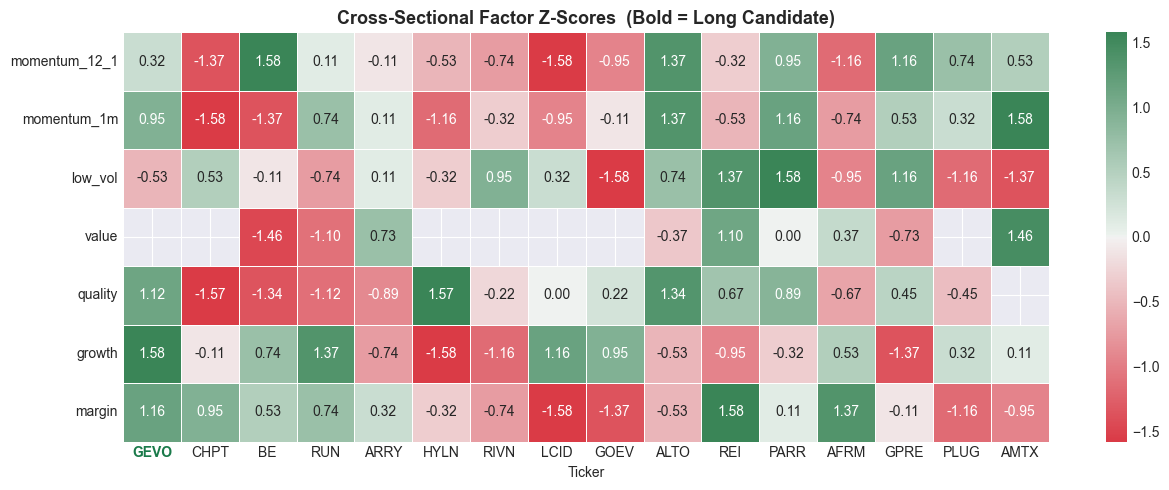

In [6]:
# Factor score heatmap
fig, ax = plt.subplots(figsize=(13, 5))
plot_data = factor_z.drop(columns='composite').T
cmap = sns.diverging_palette(10, 140, as_cmap=True)
sns.heatmap(plot_data, annot=True, fmt='.2f', cmap=cmap, center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 10})
for label in ax.get_xticklabels():
    if label.get_text() == LONG_CANDIDATE:
        label.set_fontweight('bold')
        label.set_color('#1a7a4a')
ax.set_title('Cross-Sectional Factor Z-Scores  (Bold = Long Candidate)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_factor_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure interpretation
We converted each raw factor into cross-sectional z-scores (relative ranking across the stock universe), then plotted them as a heatmap.

What this shows:
- Positive values (green-ish) mean the stock ranks stronger than peers on that factor.
- Negative values (red-ish) mean weaker relative positioning.
- The highlighted long candidate helps you quickly compare where it has factor support vs factor headwinds.

## 2. Market + Sector Beta Regression

For each stock: `r_i = α + β_mkt·r_mkt + β_sec·r_sec + ε`
running OLS on daily returns for each stock betas are sensitivities, e is residual series

Residuals `ε` represent idiosyncratic returns stripped of market and sector exposure.

In [7]:
betas     = {}
residuals = {}
alphas    = {}
rsquareds = {}

common_idx = stock_ret.index.intersection(mkt_ret.index).intersection(sec_ret.index)
X_base = add_constant(pd.DataFrame({'mkt': mkt_ret.loc[common_idx],
                                     'sec': sec_ret.loc[common_idx]}))

for ticker in ALL_STOCKS:
    y = stock_ret[ticker].loc[common_idx].dropna()
    X = X_base.loc[y.index]
    model = OLS(y, X).fit()
    betas[ticker]     = {'alpha': model.params['const'],
                         'beta_mkt': model.params['mkt'],
                         'beta_sec': model.params['sec']}
    alphas[ticker]    = model.params['const'] * 252      # annualised alpha
    residuals[ticker] = model.resid
    rsquareds[ticker] = model.rsquared

beta_df  = pd.DataFrame(betas).T
resid_df = pd.DataFrame(residuals)

beta_df.index.name = 'Ticker'
beta_df['annualised_alpha'] = pd.Series(alphas)
beta_df['r_squared']        = pd.Series(rsquareds)

beta_df.to_parquet(DATA_DIR + 'betas.parquet')
resid_df.to_parquet(DATA_DIR + 'residuals.parquet')

print('OLS Results:')
display(beta_df.round(4))

OLS Results:


,alpha,beta_mkt,beta_sec,annualised_alpha,r_squared
Ticker,,,,,
GEVO,-0.0001,2.4329,-0.4313,-0.0273,0.1252
CHPT,-0.0038,1.2964,0.5451,-0.9521,0.2020
BE,0.0017,1.1846,0.6347,0.4388,0.1869
RUN,-0.0003,2.4320,-0.3182,-0.0733,0.1441
ARRY,-0.0002,1.8254,-0.1680,-0.0518,0.1154
HYLN,-0.0007,1.4402,0.3952,-0.1820,0.1662
RIVN,-0.0014,1.7221,0.1364,-0.3423,0.1875
LCID,-0.0029,1.6190,0.1149,-0.7328,0.1509
GOEV,-0.0061,1.5345,-0.2968,-1.5248,0.0315


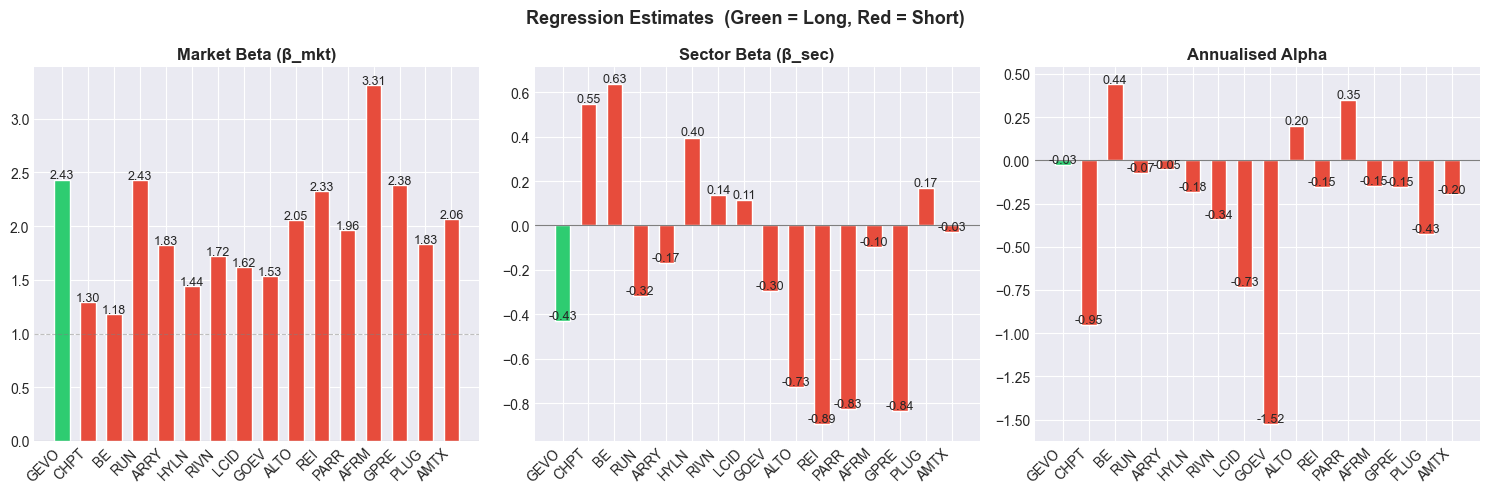

In [8]:
# Beta bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cols   = ['beta_mkt', 'beta_sec', 'annualised_alpha']
titles = ['Market Beta (β_mkt)', 'Sector Beta (β_sec)', 'Annualised Alpha']
colors = ['#2ecc71' if t == LONG_CANDIDATE else '#e74c3c' for t in beta_df.index]

for ax, col, title in zip(axes, cols, titles):
    vals = beta_df[col]
    bars = ax.bar(vals.index, vals, color=colors, edgecolor='white', width=0.6)
    ax.axhline(0, color='black', lw=0.8, alpha=0.5)
    if col == 'beta_mkt':
        ax.axhline(1, color='grey', lw=0.8, linestyle='--', alpha=0.5, label='β=1')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=45, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Regression Estimates  (Green = Long, Red = Short)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_betas.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure interpretation
We ran OLS for each stock: return explained by market return + sector return, then extracted beta and alpha estimates.

What this shows:
- **Market beta (β_mkt):** sensitivity to broad market moves.
- **Sector beta (β_sec):** sensitivity to sector-specific moves.
- **Annualized alpha:** average residual drift after controlling for market and sector.

Outcome: you can compare whether the long/short names are truly differentiated by exposure profile, not just raw return.

## 3. Residual Correlation & Clustering

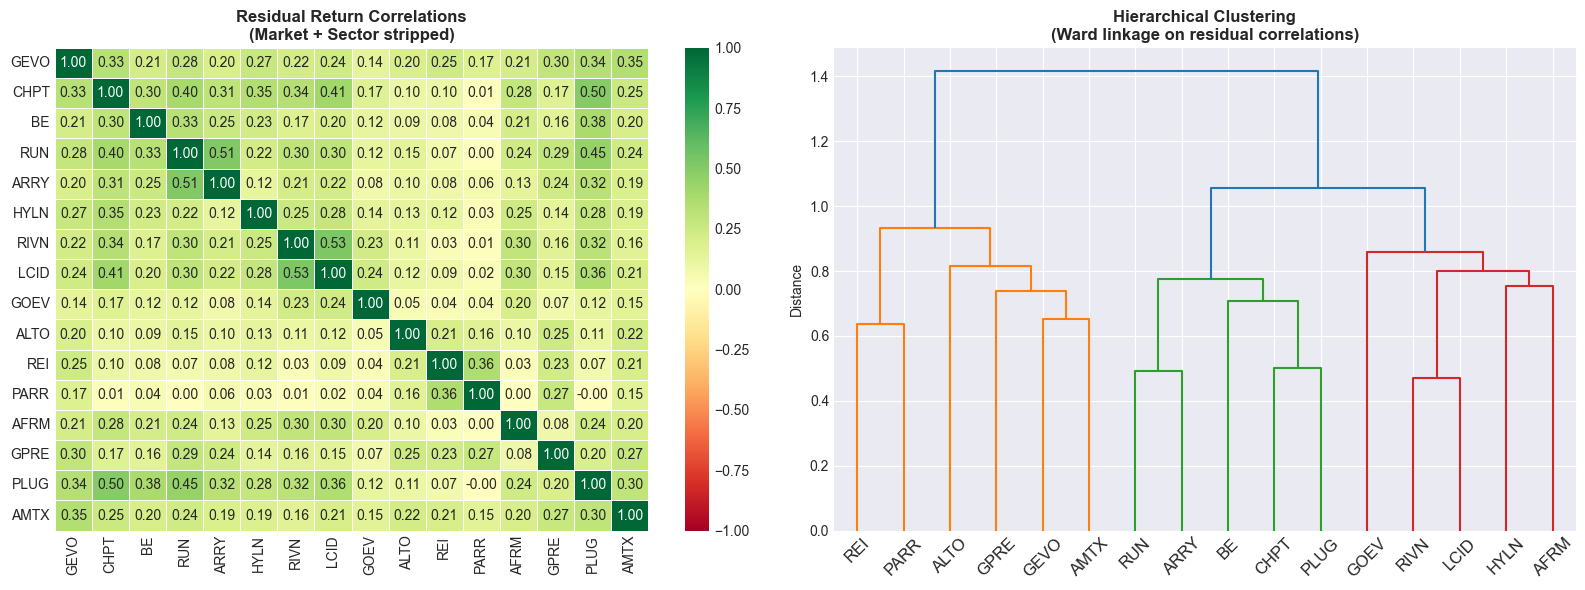

Cluster assignments:


,Cluster,Role
Ticker,,
GEVO,1,LONG
CHPT,2,SHORT
BE,2,SHORT
RUN,2,SHORT
ARRY,2,SHORT
HYLN,3,SHORT
RIVN,3,SHORT
LCID,3,SHORT
GOEV,3,SHORT


In [9]:
resid_corr = resid_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(resid_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 10}, linewidths=0.5)
axes[0].set_title('Residual Return Correlations\n(Market + Sector stripped)',
                  fontsize=12, fontweight='bold')

# Hierarchical clustering dendrogram
dist_matrix = 1 - resid_corr.abs()
np.fill_diagonal(dist_matrix.values, 0)
dist_condensed = squareform(dist_matrix.values)
Z = linkage(dist_condensed, method='ward')
dendrogram(Z, labels=resid_corr.columns.tolist(),
           ax=axes[1], leaf_rotation=45)
axes[1].set_title('Hierarchical Clustering\n(Ward linkage on residual correlations)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Distance')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_residual_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Assign clusters
n_clusters = min(3, len(ALL_STOCKS) - 1)
cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
cluster_df = pd.DataFrame({'Ticker': resid_corr.columns, 'Cluster': cluster_labels}).set_index('Ticker')
cluster_df['Role'] = ['LONG' if t == LONG_CANDIDATE else 'SHORT' for t in cluster_df.index]
print('Cluster assignments:')
display(cluster_df)

### Figure interpretation
We removed market and sector effects, computed residual-return correlations, and then performed hierarchical clustering on residual similarity.

What this shows:
- Heatmap: which stocks still co-move after common exposures are stripped out.
- Dendrogram: which names are closest in idiosyncratic behavior.
- Cluster labels: practical grouping for pair construction/diversification.

Interpretation: high positive value means two stocks have similar idiosyncratic behavior, even after stripping market/sector.
Prevents choosing shorts that are effectively the same idiosyncratic bet.

Outcome: helps avoid pairing names that are too similar and identifies cleaner relative-value relationships.
--> identify which stocks are similar to each other

## 4. PCA on Residuals

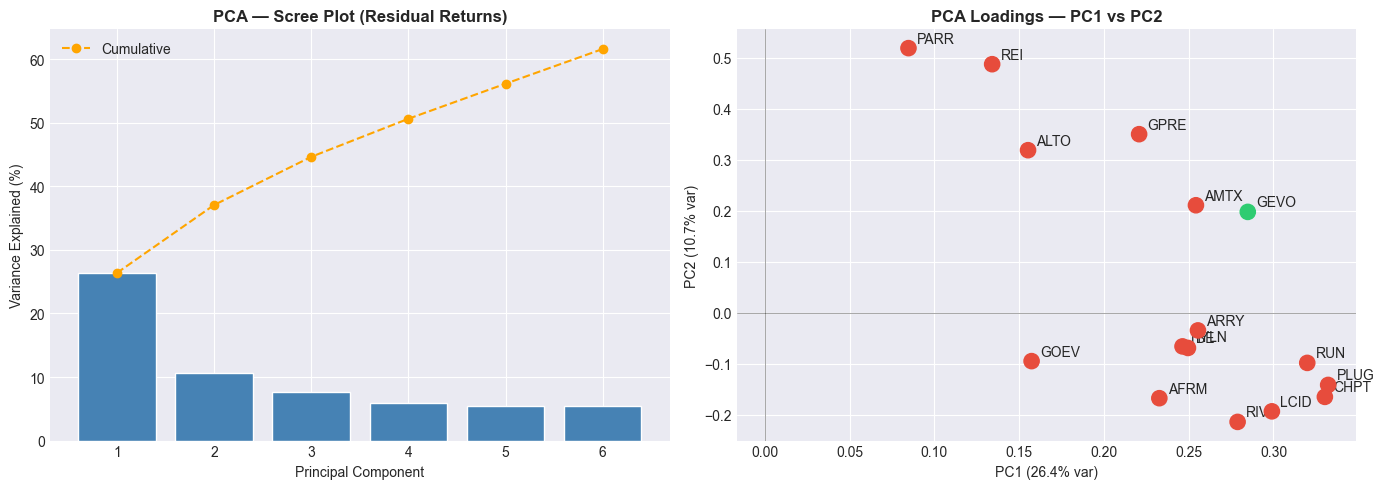

Saved pca_scores.parquet, clusters.parquet

Notebook 02 complete. Run 03_ml_selection.ipynb next.


In [10]:
scaler  = StandardScaler()
X_resid = scaler.fit_transform(resid_df.dropna())

pca = PCA(n_components=min(len(ALL_STOCKS), 6))
pca.fit(X_resid)

# Explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             np.cumsum(pca.explained_variance_ratio_) * 100,
             'o--', color='orange', label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('PCA — Scree Plot (Residual Returns)', fontsize=12, fontweight='bold')
axes[0].legend()

# Loadings for PC1 and PC2
loadings = pd.DataFrame(pca.components_[:2].T,
                        index=resid_df.columns,
                        columns=['PC1', 'PC2'])
colors = ['#2ecc71' if t == LONG_CANDIDATE else '#e74c3c' for t in loadings.index]
axes[1].scatter(loadings['PC1'], loadings['PC2'], c=colors, s=120, zorder=5)
for ticker, row in loadings.iterrows():
    axes[1].annotate(ticker, (row['PC1'], row['PC2']),
                     textcoords='offset points', xytext=(6, 4), fontsize=10)
axes[1].axhline(0, color='black', lw=0.6, alpha=0.4)
axes[1].axvline(0, color='black', lw=0.6, alpha=0.4)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[1].set_title('PCA Loadings — PC1 vs PC2', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_pca_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Save PCA scores for downstream use
pca_scores = pd.DataFrame(pca.transform(X_resid),
                           index=resid_df.dropna().index,
                           columns=[f'PC{i+1}' for i in range(pca.n_components_)])
pca_scores.to_parquet(DATA_DIR + 'pca_scores.parquet')
cluster_df.to_parquet(DATA_DIR + 'clusters.parquet')
print('Saved pca_scores.parquet, clusters.parquet')
print('\nNotebook 02 complete. Run 03_ml_selection.ipynb next.')

### Figure interpretation
We standardized residual returns and applied PCA to summarize the main latent drivers in a lower-dimensional space.

What this shows:
- Scree/cumulative plot: how much variance each principal component explains.
- PC1 vs PC2 loadings: where each stock sits along the two strongest residual risk dimensions.

Outcome: reveals hidden common themes in idiosyncratic returns and supports downstream model features / portfolio construction choices.